# Discount Impact Analysis
This notebook explores whether deeper discounts correlate with higher product ratings across different platforms.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats

client = bigquery.Client()
project_id = os.environ.get('BIGQUERY_PROJECT_ID')
dataset_id = os.environ.get('BIGQUERY_DATASET')

In [2]:
# Query the raw clean prices (excluding nulls)
query = f"""
SELECT source, product_category, discount_percent, avg_rating 
FROM `{project_id}.{dataset_id}.int_clean_prices`
WHERE discount_percent > 0 AND avg_rating IS NOT NULL
"""
df = client.query(query).to_dataframe()
df.head()

,source,product_category,discount_percent,avg_rating
0,bestbuy,Case,20.0,4.8
1,bestbuy,Case,20.0,4.8
2,bestbuy,Case,20.0,4.8
3,bestbuy,Case,20.0,4.8
4,bestbuy,Case,20.0,4.8


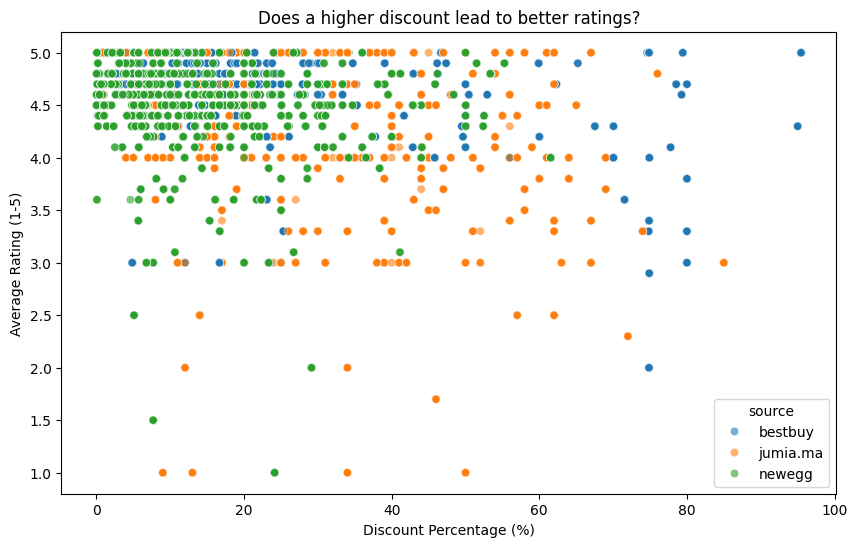

In [3]:
# Plotting the relationship between Discount and Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount_percent', y='avg_rating', hue='source', alpha=0.6)
plt.title('Does a higher discount lead to better ratings?')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Average Rating (1-5)')
plt.show()

In [4]:
# Calculate Pearson Correlation
correlation, p_value = stats.pearsonr(df['discount_percent'], df['avg_rating'])
print(f"Pearson Correlation: {correlation:.3f}")
print(f"P-Value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant relationship between discounts and ratings.")
else:
    print("Conclusion: No statistically significant relationship found.")

Pearson Correlation: -0.270
P-Value: 0.000
Conclusion: There is a statistically significant relationship between discounts and ratings.
